# Decision Tree Classifier

In [12]:
import optuna
import pandas as pd
from matplotlib import pyplot as plt
from sklearn import tree
from sklearn.tree import DecisionTreeClassifier as DTC
from sklearn.model_selection import cross_val_score, train_test_split
from sklearn.metrics import confusion_matrix, classification_report

In [2]:
data = pd.read_csv('../data/processed_smoke_detector.csv')
X = data.drop(['Fire Alarm'], axis=1)
y = data['Fire Alarm']
print(X.shape, y.shape)

(41247, 12) (41247,)


In [3]:
def objective(trial):
    criterion = trial.suggest_categorical('criterion', ['gini', 'entropy', 'log_loss'])
    splitter = trial.suggest_categorical('splitter', ['best', 'random'])
    max_depth = trial.suggest_int('max_depth', 1, 15)
    min_samples_split = trial.suggest_int('min_samples_split', 2, 10)
    min_samples_leaf = trial.suggest_int('min_samples_leaf', 1, 10)
    max_features = trial.suggest_categorical('max_features', ['sqrt', 'log2', None])


    model = DTC(criterion=criterion,
                splitter=splitter,
                max_depth=max_depth,
                min_samples_split=min_samples_split,
                min_samples_leaf=min_samples_leaf,
                max_features=max_features)
    
    score = cross_val_score(model, X, y, cv=5, scoring='f1', n_jobs=-1).mean()

    return score

In [4]:
study = optuna.create_study(direction='maximize')
study.optimize(objective, n_trials=1000, n_jobs=-1)

[I 2025-04-21 11:19:21,377] A new study created in memory with name: no-name-eced052e-084b-4d5e-8c63-ae9ff4c8c3ca
[I 2025-04-21 11:19:23,151] Trial 0 finished with value: 0.9247583589375947 and parameters: {'criterion': 'entropy', 'splitter': 'best', 'max_depth': 9, 'min_samples_split': 6, 'min_samples_leaf': 9, 'max_features': None}. Best is trial 0 with value: 0.9247583589375947.
[I 2025-04-21 11:19:23,174] Trial 5 finished with value: 0.8851067571704295 and parameters: {'criterion': 'entropy', 'splitter': 'random', 'max_depth': 12, 'min_samples_split': 3, 'min_samples_leaf': 1, 'max_features': None}. Best is trial 0 with value: 0.9247583589375947.
[I 2025-04-21 11:19:23,191] Trial 3 finished with value: 0.891375747003254 and parameters: {'criterion': 'log_loss', 'splitter': 'best', 'max_depth': 11, 'min_samples_split': 4, 'min_samples_leaf': 4, 'max_features': 'sqrt'}. Best is trial 0 with value: 0.9247583589375947.
[I 2025-04-21 11:19:23,303] Trial 1 finished with value: 0.87115885

In [5]:
print('Best params', study.best_params)
print('Best f1', study.best_value)

Best params {'criterion': 'entropy', 'splitter': 'best', 'max_depth': 12, 'min_samples_split': 2, 'min_samples_leaf': 3, 'max_features': 'sqrt'}
Best f1 0.9881870858689865


In [6]:
dtc = DTC(**study.best_params)

In [7]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, 
    test_size=0.2, 
    random_state=42,
    stratify=y
)

In [8]:
dtc.fit(X_train, y_train)

DecisionTreeClassifier(criterion='entropy', max_depth=12, max_features='sqrt',
                       min_samples_leaf=3)

In [9]:
y_pred = dtc.predict(X_test)

In [10]:
print(confusion_matrix(y_test, y_pred))
print(classification_report(y_test, y_pred))

[[1809    1]
 [   3 6437]]
              precision    recall  f1-score   support

           0       1.00      1.00      1.00      1810
           1       1.00      1.00      1.00      6440

    accuracy                           1.00      8250
   macro avg       1.00      1.00      1.00      8250
weighted avg       1.00      1.00      1.00      8250



In [13]:
text_representation = tree.export_text(dtc)
print(text_representation)

|--- feature_5 <= 19932.50
|   |--- feature_1 <= 50.30
|   |   |--- feature_6 <= 939.70
|   |   |   |--- class: 1
|   |   |--- feature_6 >  939.70
|   |   |   |--- class: 0
|   |--- feature_1 >  50.30
|   |   |--- class: 1
|--- feature_5 >  19932.50
|   |--- feature_0 <= 22.73
|   |   |--- feature_9 <= 0.50
|   |   |   |--- feature_2 <= 183.50
|   |   |   |   |--- feature_7 <= 0.03
|   |   |   |   |   |--- feature_2 <= 124.50
|   |   |   |   |   |   |--- feature_5 <= 20140.50
|   |   |   |   |   |   |   |--- class: 0
|   |   |   |   |   |   |--- feature_5 >  20140.50
|   |   |   |   |   |   |   |--- feature_1 <= 54.52
|   |   |   |   |   |   |   |   |--- class: 0
|   |   |   |   |   |   |   |--- feature_1 >  54.52
|   |   |   |   |   |   |   |   |--- class: 0
|   |   |   |   |   |--- feature_2 >  124.50
|   |   |   |   |   |   |--- feature_0 <= 1.51
|   |   |   |   |   |   |   |--- class: 1
|   |   |   |   |   |   |--- feature_0 >  1.51
|   |   |   |   |   |   |   |--- feature_4 <= 131

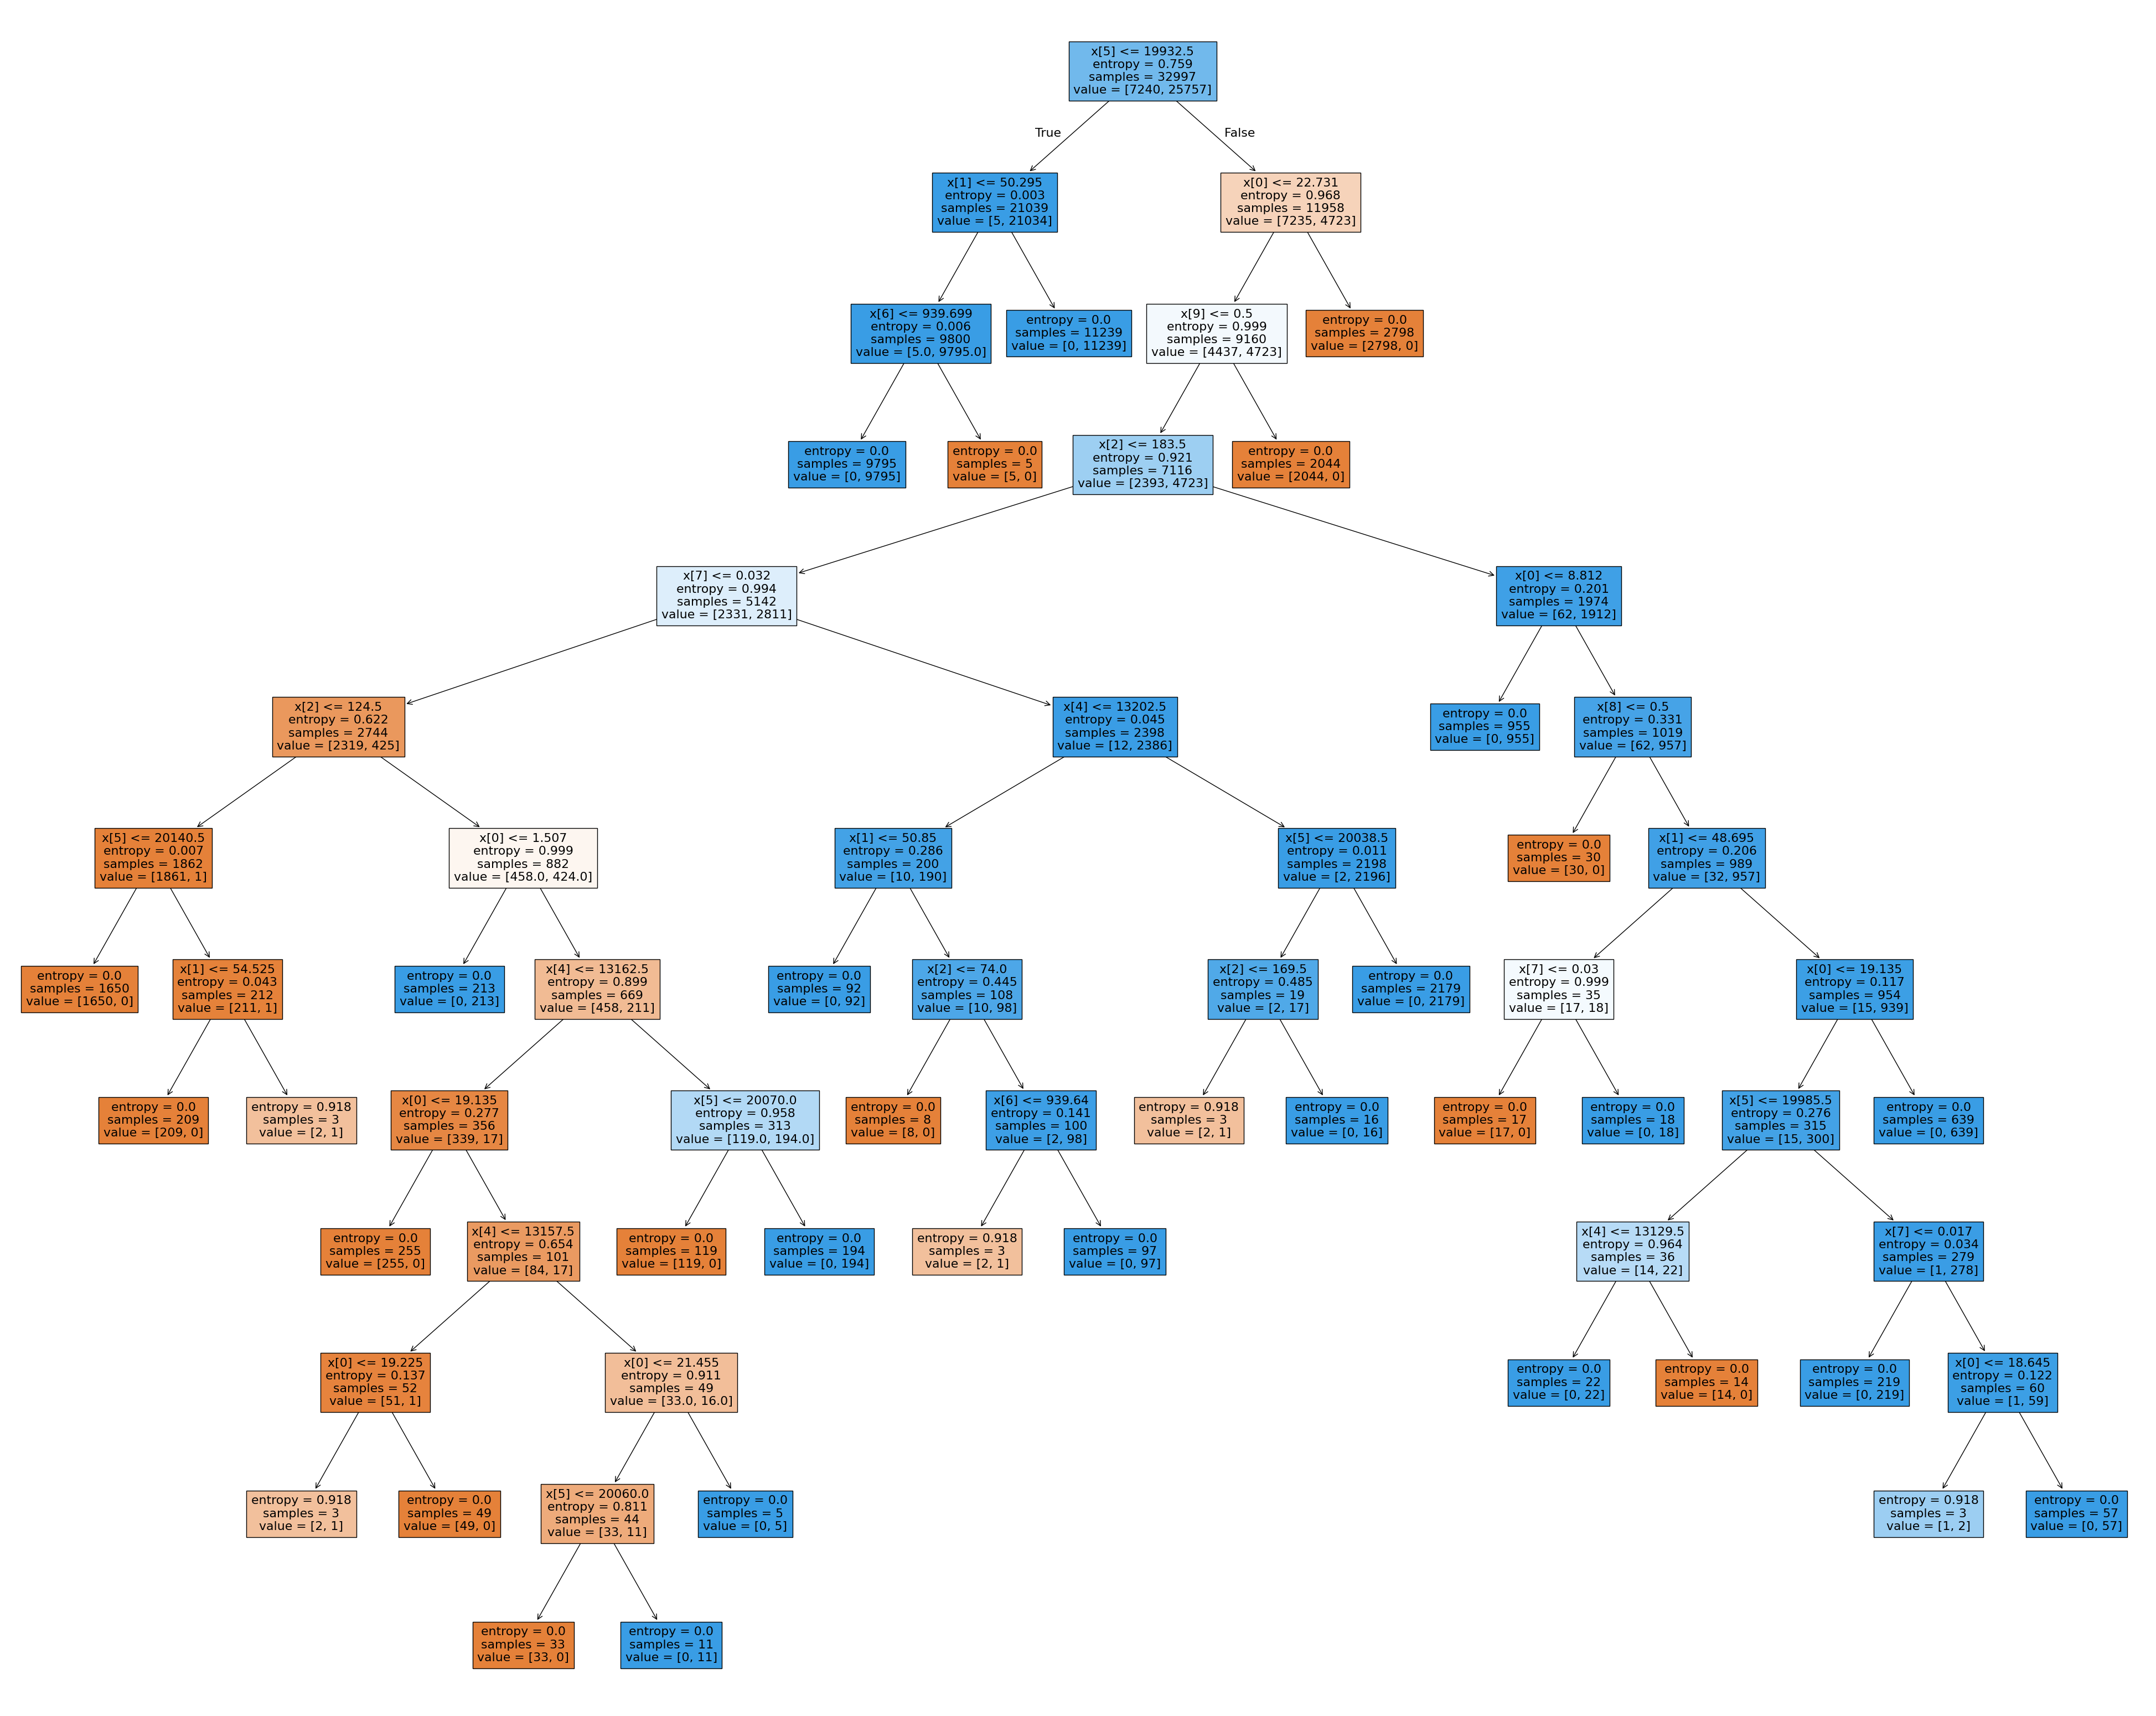

In [15]:
fig = plt.figure(figsize=(50,40))
_ = tree.plot_tree(dtc, filled=True)